In [1]:
import pandas as pd 
import torch
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
# import napari
import os

import shutil
from glob import glob

In [2]:
import sys
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

In [3]:
# img_name = '20260717T120225_pA_Activin_D4_48hr_W0027'
# channel_names = ['Sox17', 'Activin', 'FoxA2', 'Hoechst']
img_name = 'W8_pattern1_Sox17_Brachyury'
# img_name = 'W8_pattern2_Sox17_Brachyury'
# img_name = 'W14_pattern2_Sox17_Brachyury_no geltrex'
channel_names = ['Sox17', 'BMP4', 'T', 'Hoechst']
# img_name = 'W10_Cultrex_mask7'
# channel_names = ['T', 'BMP4', 'ISL1','Hoechst']

cell_df = pd.read_parquet(f'../data/stitched/{img_name}_features.parquet')
print(cell_df.shape)
cell_df.head(3)

(111511, 22)


,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,...,circularity,aspect_ratio,Sox17_mean,BMP4_mean,T_mean,Hoechst_mean,Sox17+,BMP4+,T+,Hoechst+
cell_id,,,,,,,,,,,,,,,,,,,,,
1,9.058548,629.522248,427.0,85.941125,84.158813,0.603269,0.908511,0.640180,27.763694,22.142602,...,0.757598,1.253859,264.735363,124.067916,347.723653,1366.845433,False,False,False,True
2,9.803440,4872.491400,407.0,76.526912,75.233579,0.618904,0.946512,0.740000,26.030466,20.446056,...,0.903610,1.273129,216.383292,118.837838,198.417690,758.594595,False,False,False,True
3,9.231250,7124.062500,160.0,54.970563,54.796878,0.911222,0.879121,0.661157,22.911059,9.437440,...,0.669604,2.427677,226.725000,136.756250,379.668750,1362.175000,False,False,False,True


In [4]:
if_cols = [c+'_mean' for c in channel_names if c != 'Hoechst']

# cell_df['Activin_mean'] = cell_df['Activin+'].astype(float)
cell_df['BMP4_mean'] = cell_df['BMP4+'].astype(float)

In [5]:
yif='Sox17'
predict_type = f'mask_xBMP4_y{yif}_cropped'
# predict_type = f'mask_xActivin_y{yif}'
fig_dir = f'../results/figures/{img_name}/{predict_type}'
os.makedirs(fig_dir, exist_ok=True)

In [6]:
label_mask = np.load(f'../data/stitched/{img_name}.npy')
cell_mask = np.where(label_mask > 1, True, False)
print(label_mask.shape, cell_mask.shape)

(5996, 7937) (5996, 7937)


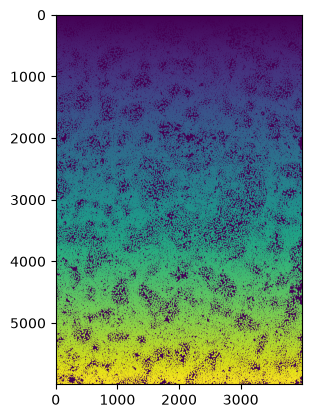

In [7]:
crop = [(0, 5996),(0, 4000)]
label_mask_ = label_mask[crop[0][0]:crop[0][1], crop[1][0]:crop[1][1]]
plt.imshow(label_mask_)

In [8]:
label_mask = label_mask_
cell_df = cell_df[cell_df.index.isin(np.unique(label_mask))]
cell_df.shape

# label_mask.shape
# crop = [(0, label_mask.shape[0]), (0, label_mask.shape[1])]

(57624, 22)

In [10]:
# X_COLS = ['Activin_mean']
X_COLS = ['BMP4_mean']

SEED = 0
SCALING = 'log1p_standard'  # 'log1p_standard' | 'arcsinh' | 'robust' -- see models.gnn.ColumnScaler;
Y_COLS = [f'{yif}_mean']

Sox17_mean: threshold=349.3, 16.2% of cells above it


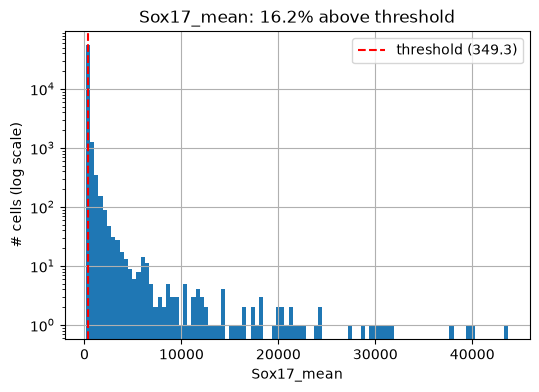

In [11]:
from tools.qc import get_bimodal_threshold

IF_BACKGROUNDS = {
    'Sox17_mean': 349.27417498634907,
    'T_mean': 384.42064880441285,
}

for col in Y_COLS:
    s = cell_df[col]
    threshold = IF_BACKGROUNDS.get(col)
    if not threshold:
        threshold = get_bimodal_threshold(pd.DataFrame({'v': s}), 'v')
    fig, ax = plt.subplots(figsize=(6, 4))
    s.hist(bins=100, ax=ax)
    ax.set_yscale('log')
    ax.set_xlabel(col)
    ax.set_ylabel('# cells (log scale)')
    frac_pos = (s > threshold).mean()
    ax.axvline(threshold, color='r', linestyle='--', label=f'threshold ({threshold:.1f})')
    ax.legend()
    ax.set_title(f'{col}: {frac_pos:.1%} above threshold')
    print(f'{col}: threshold={threshold:.1f}, {frac_pos:.1%} of cells above it')

    plt.show()

### Prediction

In [12]:
from tools.morphology import split_indices, indices_to_mask, r2_table, plot_pred_vs_actual, plot_pred_vs_actual_by_group, plot_loss_curves, local_density
from tools.qc import get_bimodal_threshold
from models.gnn import build_prediction_data, train_predictor, IFPredictor, predict_df as gnn_predict_df, border_mask, save_model
from models.gat import IFPredictorGAT

# Saved parameters
PRED_RADIUS = 30  # px -- create a graph (every pair within radius is connected), NOT k-NN
NUM_LAYERS = 3
NORMALIZE_DATA = False
HIDDEN_DIM = 64
EMBEDDING_DIM = 64
LR = 1e-4
NUM_HEADS = 2
DISTANCE_INIT = True
TWO_PART = True

USE_AMP = True          # Autocast 
USE_CHECKPOINT = False  # Recompute forward instead of storing
TRAIN_DEVICE = 'mps'

N = len(cell_df)
centroids = cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)

# BORDER_RADIUS = NUM_LAYERS * PRED_RADIUS
BORDER_RADIUS = PRED_RADIUS

crop_y0, crop_x0 = crop[0][0], crop[1][0]
local_centroids = centroids - np.array([crop_y0, crop_x0], dtype=np.float32)
is_border = border_mask(local_centroids, label_mask.shape, BORDER_RADIUS)
valid_target_idx = np.where(~is_border)[0]
print(f'{is_border.sum()} / {N} cells within {BORDER_RADIUS}px ({NUM_LAYERS} layers x {PRED_RADIUS}px) of the CROPPED border -- excluded as targets')

train_pos, val_pos, test_pos = split_indices(len(valid_target_idx), val_frac=0.15, test_frac=0.15, seed=SEED)
train_idx, val_idx, test_idx = valid_target_idx[train_pos], valid_target_idx[val_pos], valid_target_idx[test_pos]
train_mask = indices_to_mask(train_idx, N)
val_mask = indices_to_mask(val_idx, N)
test_mask = indices_to_mask(test_idx, N)

# TWO_PART uses models.gnn.HurdleScaler for Y_COLS instead of the usual ColumnScaler:
# exactly 0 at/below the bimodal threshold (same threshold used for the classifier's
# positive/negative label), in (0, 1] above it. If the automatic threshold (see the
# distribution-check cell above) looks off for a given column, override it here, e.g.
# custom_background={yif + '_mean': 500},  -- same override ColumnScaler already
# uses for its background floor, reused here as the hurdle threshold.
pred_data = build_prediction_data(
    cell_df, if_cols, radius=PRED_RADIUS, x_cols=X_COLS, train_idx=train_idx, scaling=SCALING,
    y_cols=Y_COLS,
    no_background_cols=['Activin_mean', 'BMP4_mean'],
    no_transform_cols=['Activin_mean', 'BMP4_mean'],
    no_scale_cols=['Activin_mean', 'BMP4_mean'],
    custom_background=IF_BACKGROUNDS,
    normalize_data=NORMALIZE_DATA,
    two_part=TWO_PART,
)
print("x_cols (self + neighbors, via the graph's self-loop):", pred_data['x_cols'])
print('y_cols (predicted):', pred_data['y_cols'])
print(f"{N} cells, {pred_data['edge_index'].shape[1]} directed edges incl. self-loops (radius={PRED_RADIUS}px)")
if TWO_PART:
    print('y_positive fraction (whole df, incl. non-train cells):', pred_data['y_positive'].mean(dim=0).tolist())
    print('HurdleScaler threshold_ (raw units, at/below this -> scaled 0):', pred_data['y_scaler'].threshold_.tolist())
    print('HurdleScaler scale_ (train max, above threshold, post-transform):', pred_data['y_scaler'].scale_.tolist())

1443 / 57624 cells within 30px (3 layers x 30px) of the CROPPED border -- excluded as targets
x_cols (self + neighbors, via the graph's self-loop): ['BMP4_mean']
y_cols (predicted): ['Sox17_mean']
57624 cells, 437774 directed edges incl. self-loops (radius=30px)
y_positive fraction (whole df, incl. non-train cells): [0.16238026320934296]
HurdleScaler threshold_ (raw units, at/below this -> scaled 0): [349.274169921875]
HurdleScaler scale_ (train max, above threshold, post-transform): [10.677948951721191]


In [13]:
# check if the dynamic range is good enough for prediction
data = pd.DataFrame(pred_data['y'], columns=pred_data['y_cols'])
for i, x in enumerate(pred_data['x_cols']):
    data[x] = pred_data['x'][:, i]

data['centroid_x'] = cell_df['centroid_x'].values
data['centroid_y'] = cell_df['centroid_y'].values
print(data.shape)
data.tail(2)

(57624, 4)


,Sox17_mean,BMP4_mean,centroid_x,centroid_y
57622,0.000000,1.0,57.696429,5992.000000
57623,0.445072,0.0,664.228571,5991.628571


,Sox17_mean,BMP4_mean,centroid_x,centroid_y
count,57624.000000,57624.000000,57624.000000,57624.000000
mean,0.061279,0.036374,1989.267276,3040.221651
std,0.154694,0.187220,1157.397188,1740.220188
min,0.000000,0.000000,3.090164,3.430000
25%,0.000000,0.000000,984.446321,1517.096123
50%,0.000000,0.000000,1988.236271,3042.019357
75%,0.000000,0.000000,2990.035654,4566.126956
max,1.000000,1.000000,4014.688633,5992.000000


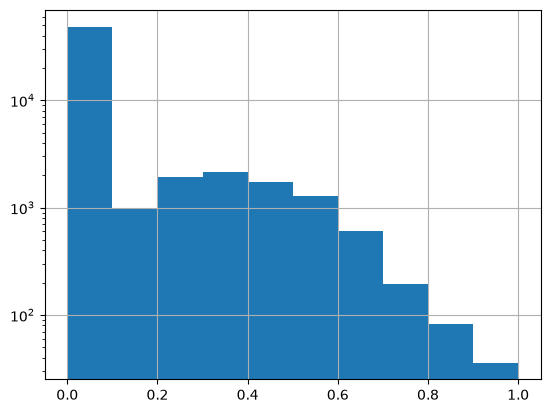

In [14]:
data[f'{yif}_mean'].hist()
plt.semilogy()
data.describe()

In [15]:
# data.to_csv(f'../data/training/{img_name}_scaled.csv')

import gc
import torch

gc.collect()
torch.mps.empty_cache()

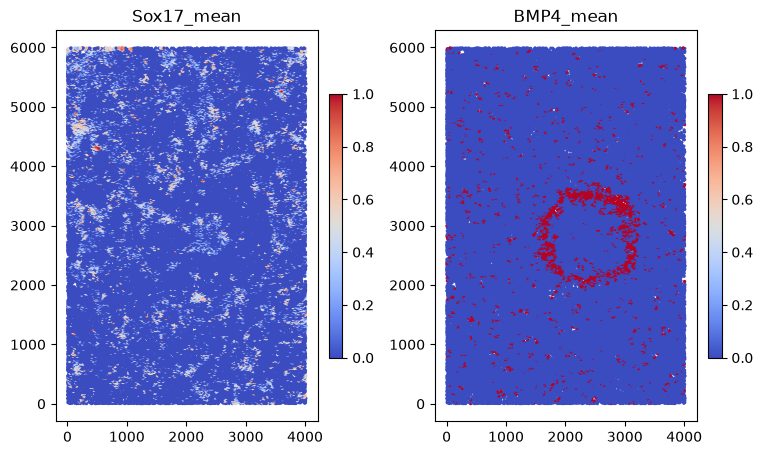

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [x for x in data.columns if 'centroid' not in x]
fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs = axs.flatten()

for i, col in enumerate(cols):
    ax = axs[i]
    sc = ax.scatter(
        data['centroid_x'], data['centroid_y'],
        c=data[col], cmap='coolwarm',
        s=2
    )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# Hide unused subplots
for j in range(len(cols), len(axs)):
    axs[j].set_visible(False)

fig.tight_layout()
plt.savefig(f'{fig_dir}/features.png', dpi=300)
plt.show()

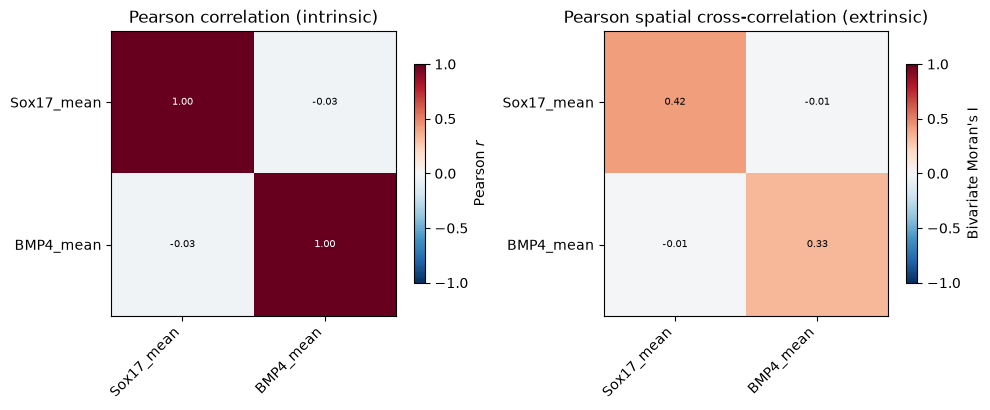

In [17]:
from tools.morphology import plot_correlation_heatmap, plot_spatial_cross_correlation

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_correlation_heatmap(data, cols, title=f'Pearson correlation (intrinsic)', corr_type='pearson', ax=axs[0])
plot_spatial_cross_correlation(data, cols, title='Pearson spatial cross-correlation (extrinsic)', corr_type='pearson', edge_index=pred_data['edge_index'], ax=axs[1])
plt.tight_layout()

/Users/allywang/Desktop/work/F2026/OptoBMP/notebooks/../src/models/gnn.py:1198: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


GNN:   0%|          | 0/500000 [00:00<?, ?it/s]

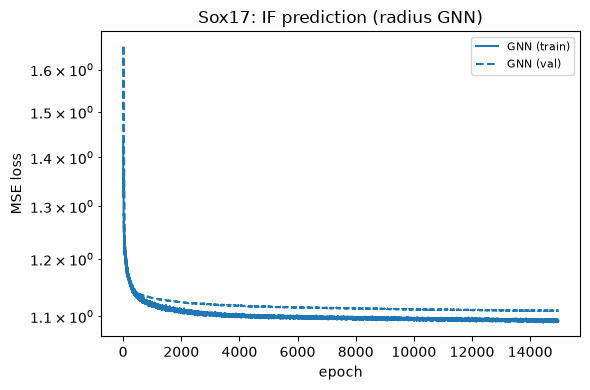

,R2,MAE
feature,,
Sox17_mean,-0.583524,0.173811


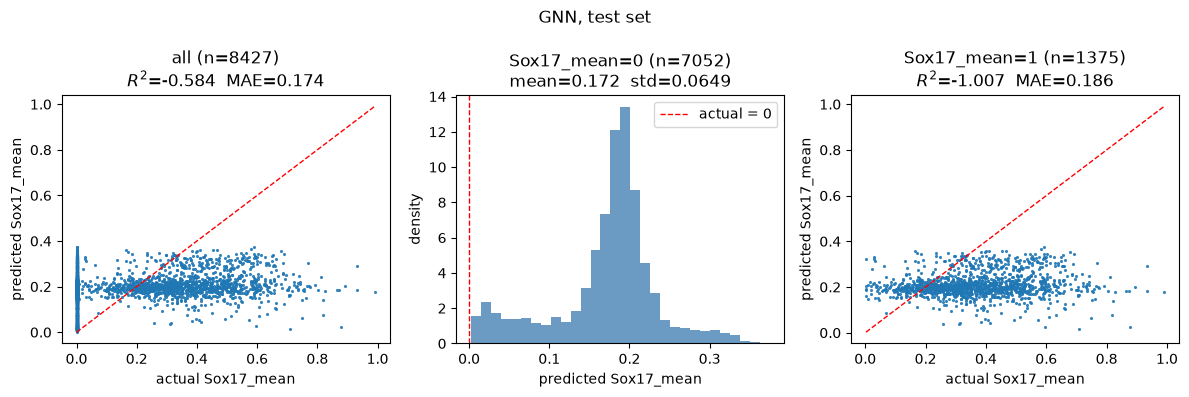

In [19]:
GNN_KWARGS = dict(
    in_channels=len(pred_data['x_cols']),
    num_outputs=len(pred_data['y_cols']),
    num_layers=NUM_LAYERS, 
    hidden_channels=HIDDEN_DIM,
    normalize_data=NORMALIZE_DATA,
    use_checkpoint=USE_CHECKPOINT,
    two_part=TWO_PART,
)

torch.manual_seed(SEED)
gnn_model = IFPredictor(**GNN_KWARGS)

gnn_history = train_predictor(
    gnn_model, pred_data, train_mask, val_mask, desc='GNN', 
    epochs=500_000, patience=500, lr=LR, use_amp=USE_AMP, device=TRAIN_DEVICE,
)
fig_gnn_loss = plot_loss_curves({'GNN': gnn_history}, title=f'{yif}: IF prediction (radius GNN)')
plt.show()

gnn_pred_test, gnn_true_test = gnn_predict_df(gnn_model, pred_data, test_mask, cell_df.index,  y_scaler=None)
gnn_r2 = r2_table(gnn_true_test, gnn_pred_test)
display(gnn_r2)

y_positive_series = pd.Series(pred_data['y_positive'].numpy().ravel(), index=cell_df.index)
fig_gnn_pred = plot_pred_vs_actual_by_group(gnn_true_test, gnn_pred_test, y_positive_series, title='GNN, test set')
plt.show()

fig_gnn_loss.savefig(f'{fig_dir}/gnn_loss_curve.png', dpi=300, bbox_inches='tight')
fig_gnn_pred.savefig(f'{fig_dir}/gnn_r2.png', dpi=300, bbox_inches='tight')

save_model(
    f'../results/models/{img_name}_{predict_type}_gnn.pt', gnn_model, GNN_KWARGS, pred_data, radius=PRED_RADIUS,
    normalize_data=NORMALIZE_DATA,
)

In [20]:
gc.collect()
torch.mps.empty_cache()

In [ ]:
GAT_KWARGS = dict(
    in_channels=len(pred_data['x_cols']),
    num_outputs=len(pred_data['y_cols']),
    num_layers=NUM_LAYERS,
    hidden_channels=HIDDEN_DIM,
    heads=NUM_HEADS,
    distance_init=DISTANCE_INIT,
    use_checkpoint=USE_CHECKPOINT,
    two_part=TWO_PART,
)

torch.manual_seed(SEED)
gat_model = IFPredictorGAT(**GAT_KWARGS)
gat_history = train_predictor(
    gat_model, pred_data, train_mask, val_mask, desc='GAT',
    epochs=5000, lr=LR, patience=100, use_amp=USE_AMP,
    # device=TRAIN_DEVICE, 
    device='cpu'
    # batch_size=32, num_neighbors=[-1, 5, 5, 5]
)
fig_gat_loss = plot_loss_curves({'GAT': gat_history}, title=f'{yif}: IF prediction (radius GAT)')
plt.show()

gat_pred_test, gat_true_test = gnn_predict_df(gat_model, pred_data, test_mask, cell_df.index,  y_scaler=None)
gat_r2 = r2_table(gat_true_test, gat_pred_test)
display(gat_r2)

y_positive_series = pd.Series(pred_data['y_positive'].numpy().ravel(), index=cell_df.index)
fig_gat_pred = plot_pred_vs_actual_by_group(gat_true_test, gat_pred_test, y_positive_series, title='GAT, test set')
plt.show()

fig_gat_loss.savefig(f'{fig_dir}/gat_loss_curve.png', dpi=300, bbox_inches='tight')
fig_gat_pred.savefig(f'{fig_dir}/gat_r2.png', dpi=300, bbox_inches='tight')

save_model(
    f'../results/models/{img_name}_{predict_type}_gat.pt', gat_model, GAT_KWARGS, pred_data, radius=PRED_RADIUS,
    normalize_data=NORMALIZE_DATA
)

/Users/allywang/Desktop/work/F2026/OptoBMP/notebooks/../src/models/gnn.py:1198: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


GAT:   0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
# comparison = pd.concat({'GNN (fixed weights)': gnn_r2, 'GAT (learned attention)': gat_r2}, axis=1)
# display(comparison)

### Gradient-based neighbor sensitivity

In [ ]:
# One list entry per GNN layer (models.gnn.IFPredictor.message_sensitivity_by_layer)
# -- same (E,) shape as GAT's layer_attentions below, but each entry is a computed
# grad-times-message contribution rather than a learned attention weight, since
# WeightedRadiusConv has nothing learned to read off an edge directly. `E` here
# includes each cell's own self-loop edge (distance 0) alongside its neighbors'.
layer_sensitivities = gnn_model.message_sensitivity_by_layer(
    pred_data['x'], pred_data['edge_index'], pred_data['edge_weight']
)

centroids_t = torch.from_numpy(centroids)
src, dst = pred_data['edge_index']
edge_dist = torch.norm(centroids_t[src] - centroids_t[dst], dim=1)

# One ROW per layer -- only the FIRST layer's sensitivity is a direct function of
# these raw x_cols values; deeper layers' sensitivity is built from the
# embeddings earlier layers produced, same caveat as the GAT section below.
x_cols = pred_data['x_cols']
n_panels = 1 + len(x_cols)
n_layers = len(layer_sensitivities)
fig, axes = plt.subplots(n_layers, n_panels, figsize=(5 * n_panels, 5 * n_layers), sharey=True, squeeze=False)

for layer_idx, layer_sens in enumerate(layer_sensitivities):
    ax = axes[layer_idx, 0]
    ax.scatter(edge_dist.numpy(), layer_sens.numpy(), s=2, alpha=0.15, linewidths=0)
    corr = np.corrcoef(edge_dist.numpy(), layer_sens.numpy())[0, 1]
    ax.set_xlabel('edge distance (px) -- 0 == self-loop')
    ax.set_ylabel(f'layer {layer_idx} sensitivity (grad x message)')
    ax.set_title(f'layer {layer_idx}: distance (r = {corr:.3f})')

    for j, col in enumerate(x_cols):
        ax = axes[layer_idx, j + 1]
        values = pred_data['x'][src, j].numpy()
        ax.scatter(values, layer_sens.numpy(), s=2, alpha=0.15, linewidths=0)
        corr = np.corrcoef(values, layer_sens.numpy())[0, 1]
        ax.set_xlabel(f'{col} (scaled)')
        ax.set_title(f'layer {layer_idx}: {col} (r = {corr:.3f})')

fig.suptitle('GNN sensitivity vs. distance and marker value, by layer', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gnn_sensitivity_corrs.png', dpi=300, bbox_inches='tight')
plt.show()

# Cell below (single-example-cell map) uses the FINAL layer's sensitivity -- the
# one closest to the prediction head.
sens_weights = layer_sensitivities[-1]

In [ ]:
# One example (held-out test) cell: one sensitivity panel PER LAYER (positions are
# identical across layers -- only the coloring/sensitivity values change, since each
# layer's messages are a genuinely different, downstream quantity from the previous
# layer's, see the "distance and marker value, by layer" cell above), then one
# panel per marker column (these don't depend on layer at all, so shown once
# rather than repeated).

example_cell_pos = np.random.choice(test_idx)
# example_cell_pos = test_idx[i]
mask_edges = (dst == example_cell_pos)
field_pos = src[mask_edges].numpy()  # includes the self-loop -- one of these IS example_cell_pos itself

n_layers = len(layer_sensitivities)
n_panels = n_layers + len(x_cols)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))

for layer_idx, layer_sens in enumerate(layer_sensitivities):
    field_sens = layer_sens[mask_edges].numpy()
    ax = axes[layer_idx]
    sc = ax.scatter(centroids[field_pos, 1], centroids[field_pos, 0], c=field_sens, cmap='viridis', s=100)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*', label='center cell')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label='sensitivity (grad x message)', shrink=0.4)
    ax.set_title(f'layer {layer_idx}: sensitivity')
    ax.legend()

for j, col in enumerate(x_cols):
    ax = axes[n_layers + j]
    values = pred_data['x'][field_pos, j].numpy()
    sc = ax.scatter(centroids[field_pos, 1], centroids[field_pos, 0], c=values, cmap='coolwarm', s=60)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label=f'{col} (scaled)', shrink=0.4)
    ax.set_title(col)

fig.suptitle(f'GNN sensitivity by layer vs. marker value (self + neighbors): cell {cell_df.index[example_cell_pos]}', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gnn_sensitivity_example.png', dpi=300, bbox_inches='tight')
plt.show()

### Understanding the GAT: attention weights

`WeightedNeighborConv` (the fixed-weight GNN) weights every neighbor by a deterministic
function of distance alone -- there's nothing to "interpret" there beyond the decay
curve itself. `GATConv` (the GAT) instead LEARNS its neighbor weighting, so inspecting
those learned attention weights directly shows what the model actually uses, rather
than assuming distance is what matters.

`GATConv` hands back the exact per-edge attention coefficient via
`return_attention_weights=True` -- softmax-normalized so each cell's incoming
attention still sums to 1, same property as the fixed GNN's `edge_weight`, just
learned instead of fixed. Two things worth checking:
- **Attention vs. distance**: if attention just tracks the same exponential decay the
  fixed GNN assumes, geometry is doing all the work and the learned attention isn't
  adding anything beyond it. If it doesn't correlate with distance, the model has
  found something in the neighbor FEATURES themselves that geometry alone can't explain.
- **Per-cell attention map**: for one example cell, which of its neighbors does the
  model actually lean on -- the physically closest ones, or ones with a similar/
  dissimilar marker profile regardless of exact distance?

/var/folders/1g/26g72_qd5qn5k3q89zh7_6240000gn/T/ipykernel_31761/1161324225.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  centroids_t = torch.from_numpy(centroids)


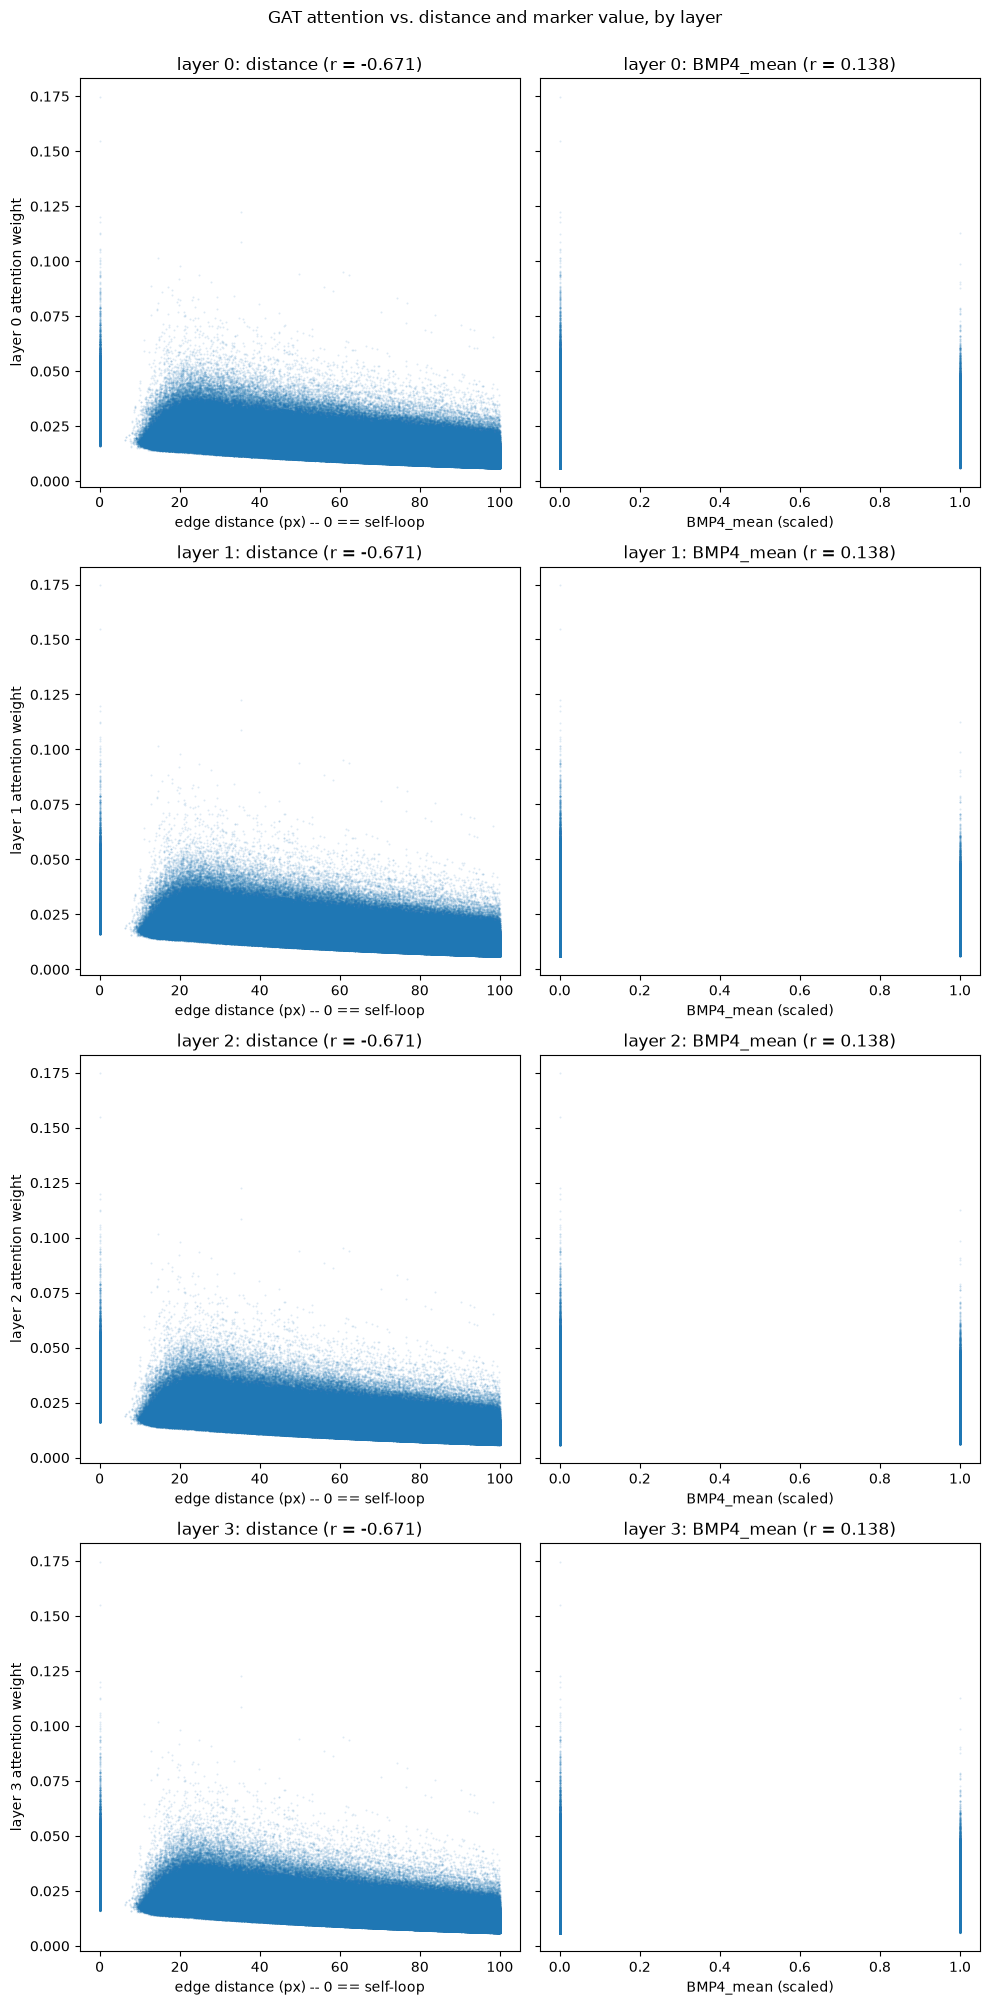

In [ ]:
edge_attr = pred_data['edge_weight'].unsqueeze(-1)
# One list entry per GAT layer (models.gat.RadiusGAT.attention_by_layer) --
# with NUM_LAYERS > 1 there's no longer a single "the" attention weight per edge:
# every non-final layer has heads > 1 (concat=True), so a single conv(...,
# return_attention_weights=True) call on ONE layer comes back (E, heads), not the
# (E,) a scalar-per-edge plot needs -- attention_by_layer head-averages each layer
# down to (E,) and replays the SAME forward computation (dropout disabled) so the
# captured attention matches what a real forward pass actually used. `E` includes
# each cell's own self-loop edge (distance 0) alongside its neighbors'.
layer_attentions = gat_model.encoder.attention_by_layer(pred_data['x'], pred_data['edge_index'], edge_attr)

centroids_t = torch.from_numpy(centroids)
src, dst = pred_data['edge_index']
edge_dist = torch.norm(centroids_t[src] - centroids_t[dst], dim=1)

# One ROW per layer -- only the FIRST layer's attention operates directly on these raw
# x_cols values; deeper layers' attention operates on the embeddings that
# resulted from earlier layers, so a correlation there reflects an indirect/aggregate
# relationship with the raw marker, not a direct one.
x_cols = pred_data['x_cols']
n_panels = 1 + len(x_cols)
n_layers = len(layer_attentions)
fig, axes = plt.subplots(n_layers, n_panels, figsize=(5 * n_panels, 5 * n_layers), sharey=True, squeeze=False)

for layer_idx, layer_att in enumerate(layer_attentions):
    ax = axes[layer_idx, 0]
    ax.scatter(edge_dist.numpy(), layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
    corr = np.corrcoef(edge_dist.numpy(), layer_att.numpy())[0, 1]
    ax.set_xlabel('edge distance (px) -- 0 == self-loop')
    ax.set_ylabel(f'layer {layer_idx} attention weight')
    ax.set_title(f'layer {layer_idx}: distance (r = {corr:.3f})')

    for j, col in enumerate(x_cols):
        ax = axes[layer_idx, j + 1]
        values = pred_data['x'][src, j].numpy()
        ax.scatter(values, layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
        corr = np.corrcoef(values, layer_att.numpy())[0, 1]
        ax.set_xlabel(f'{col} (scaled)')
        ax.set_title(f'layer {layer_idx}: {col} (r = {corr:.3f})')

fig.suptitle('GAT attention vs. distance and marker value, by layer', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gat_attention_corrs.png', dpi=300, bbox_inches='tight')
plt.show()

# Cell below (single-example-cell map) uses the FINAL layer's attention -- the one
# that most directly determines what reaches the prediction head.
att_weights = layer_attentions[-1]

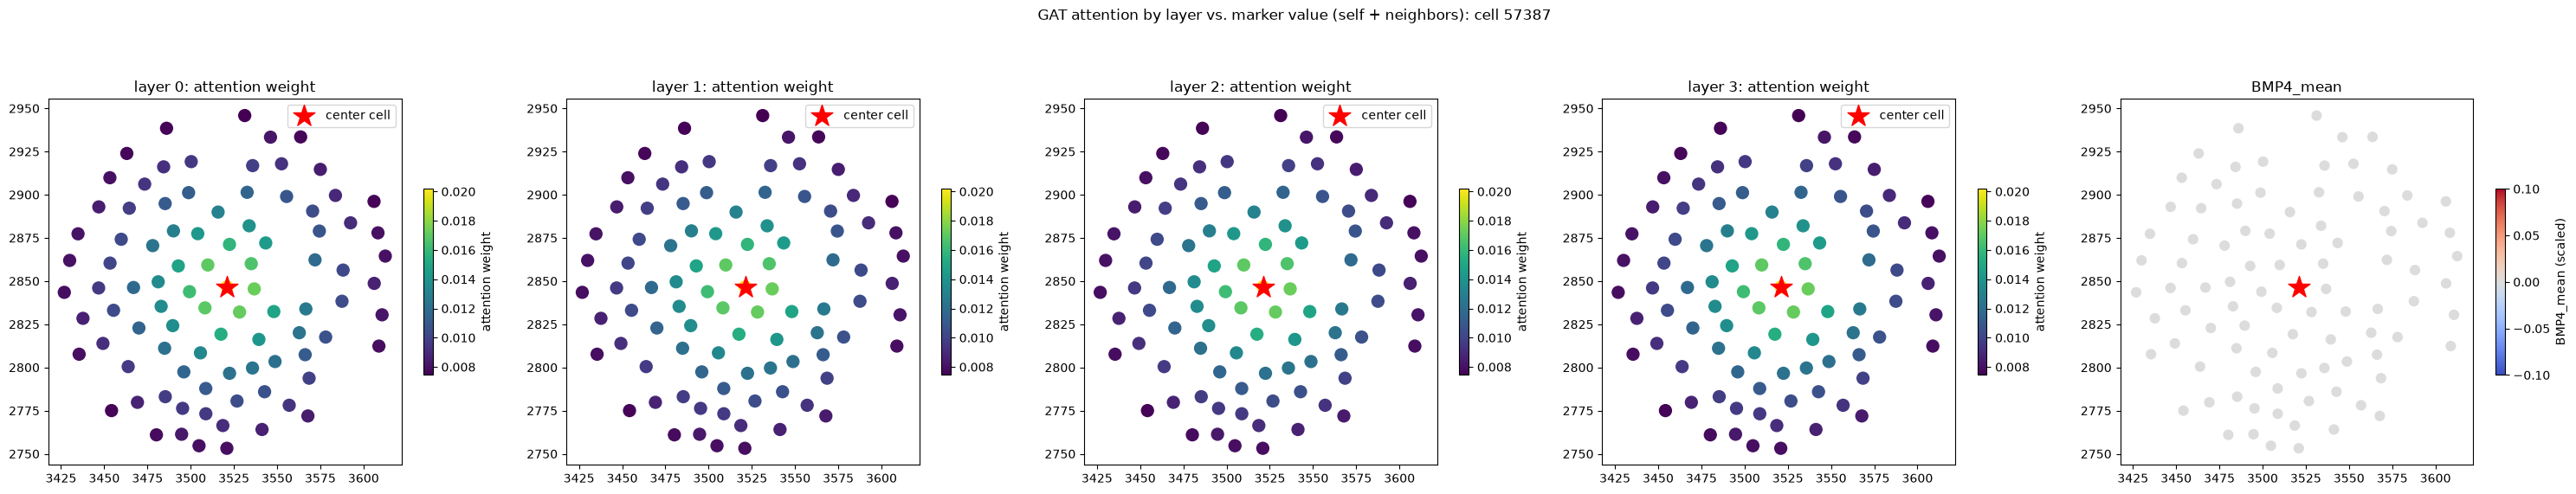

In [ ]:
# One example (held-out test) cell: one attention-weight panel PER LAYER (positions are
# identical across layers -- only the coloring/attention values change, since layer 1's
# attention is a genuinely different, separately-learned quantity from layer 0's, see
# the "distance and marker value, by layer" cell above), then one panel per marker
# column (these don't depend on layer at all, so shown once rather than repeated).

example_cell_pos = np.random.choice(test_idx)
# example_cell_pos = test_idx[i]
mask_edges = (dst == example_cell_pos)
field_pos = src[mask_edges].numpy()  # includes the self-loop -- one of these IS example_cell_pos itself

n_layers = len(layer_attentions)
n_panels = n_layers + len(x_cols)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))

for layer_idx, layer_att in enumerate(layer_attentions):
    field_att = layer_att[mask_edges].numpy()
    ax = axes[layer_idx]
    sc = ax.scatter(centroids[field_pos, 1], centroids[field_pos, 0], c=field_att, cmap='viridis', s=100)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*', label='center cell')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label='attention weight', shrink=0.4)
    ax.set_title(f'layer {layer_idx}: attention weight')
    ax.legend()

for j, col in enumerate(x_cols):
    ax = axes[n_layers + j]
    values = pred_data['x'][field_pos, j].numpy()
    sc = ax.scatter(centroids[field_pos, 1], centroids[field_pos, 0], c=values, cmap='coolwarm', s=60)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label=f'{col} (scaled)', shrink=0.4)
    ax.set_title(col)

fig.suptitle(f'GAT attention by layer vs. marker value (self + neighbors): cell {cell_df.index[example_cell_pos]}', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gat_attention_example.png', dpi=300, bbox_inches='tight')
plt.show()